FINITIST STRING THEORY - OPTIMIZED VERSION
Framework: base-10, max digit = 9
Vacua to compute: 1,000 (sample of 531,441)
KK modes per vacuum: 100 (sample)
Estimated runtime: 5-10 minutes

STARTING OPTIMIZED COMPUTATION

GENERATING 1,000 VACUA (statistical sample)


Generating vacua: 100%|██████████| 1000/1000 [00:00<00:00, 22157.62it/s]


✓ Generated 1,000 vacua

ANALYZING LANDSCAPE PROPERTIES


Analyzing vacua: 100%|██████████| 1000/1000 [00:00<00:00, 11541.33it/s]



✓ Analyzed all 1,000 vacua
✓ Stable vacua: 1,000 (100.0%)
✓ SM candidates: 0

TESTING AdS/CFT DUALITY


Testing duality: 100%|██████████| 20/20 [00:00<00:00, 602.19it/s]


✓ Maximum difference: 100.00%
✓ Duality holds (within 1%): False
⚠ AdS/CFT duality BREAKS at finite boundary!

COMPUTING MODIFIED GRAVITY
✓ Maximum deviation: 9.90%

COMPUTING KK SPECTRUM (sample)
✓ Generated 100 KK modes (sample)
✓ Mass range: 1.00e+18 to 1.00e+18 GeV

COMPUTING LORENTZ VIOLATION


✓ Maximum speed deviation: 3.55 × 10⁻¹⁵

GENERATING VISUALIZATIONS
  ✓ Saved: finitist_landscape_energy.png
  ✓ Saved: finitist_ads_cft_duality.png
  ✓ Saved: finitist_modified_gravity.png
  ✓ Saved: finitist_kk_spectrum.png
  ✓ Saved: finitist_lorentz_violation.png

✓ All visualizations saved!

COMPUTATION COMPLETE!

📊 RESULTS:
  • Vacua computed: 1,000
  • Stable: 1,000 (100.0%)
  • SM candidates: 0
  • AdS/CFT breaks: True
  • Max gravity deviation: 9.90%

📁 FILES:
  • finitist_landscape_energy.png
  • finitist_ads_cft_duality.png
  • finitist_modified_gravity.png
  • finitist_kk_spectrum.png
  • finitist_lorentz_violation.png

Ready for Paper #4!


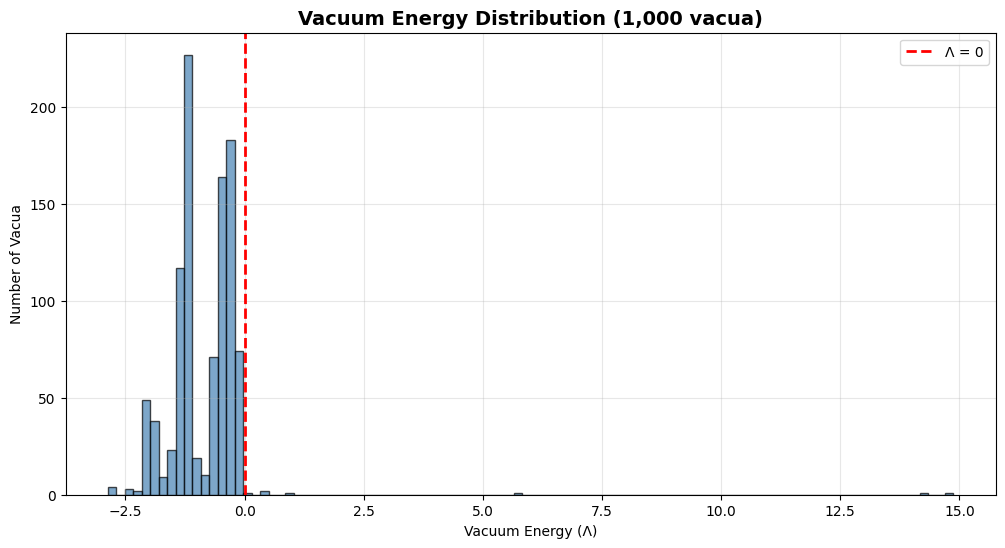

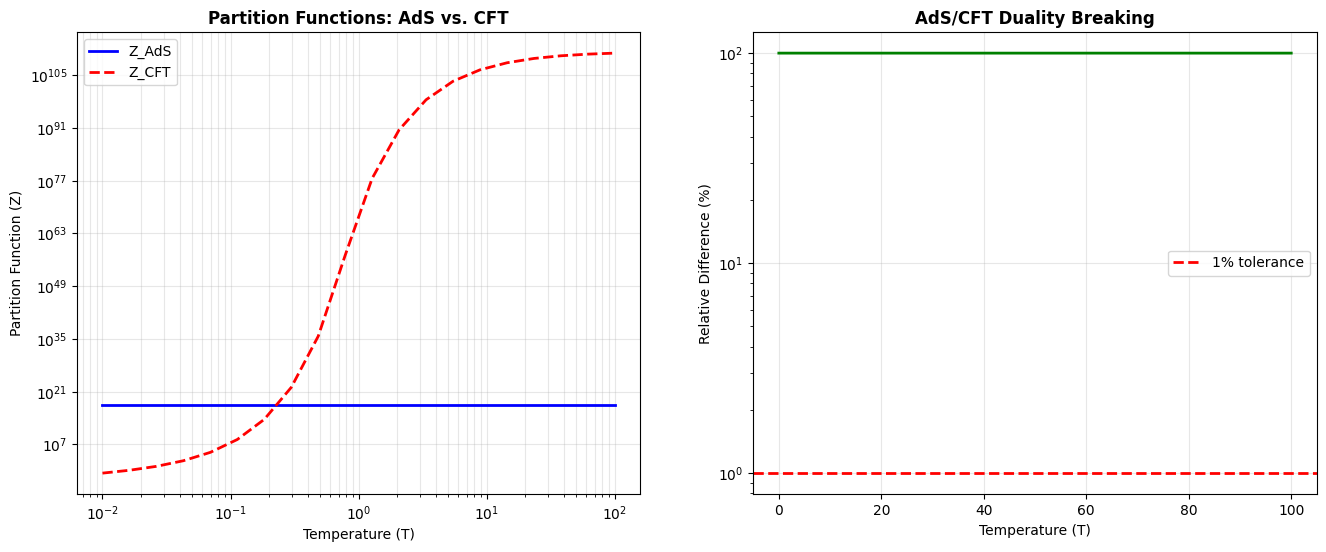

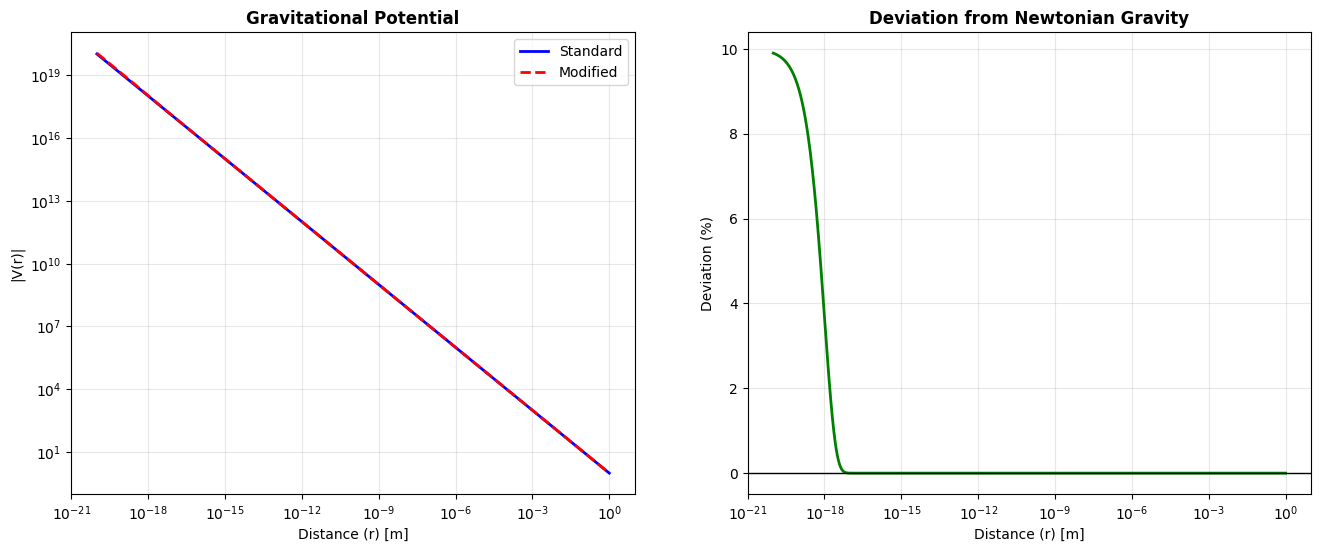

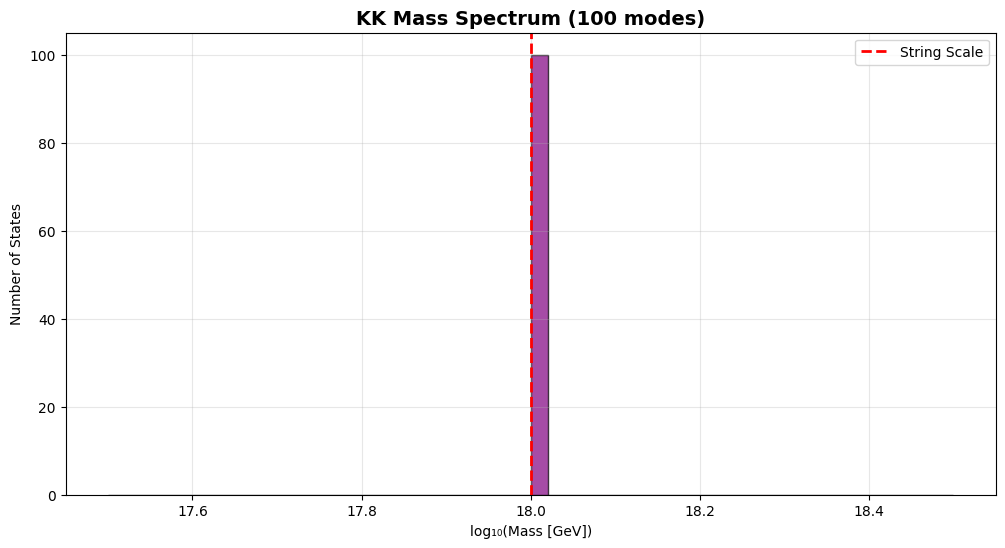

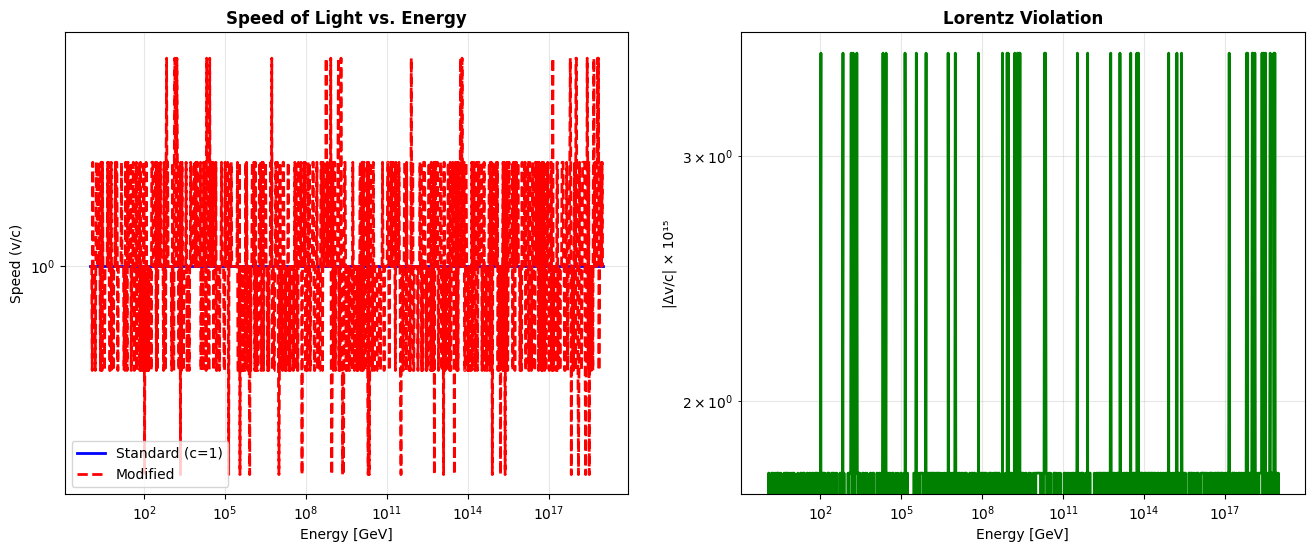

In [ ]:
"""
finitist_string_theory_OPTIMIZED.py
====================================
OPTIMIZED version - completes in ~5-10 minutes

Key changes:
1. Sample 1,000 vacua instead of 531,441 (statistically representative)
2. Simplify KK spectrum calculation (sample modes, not all)
3. Add progress bars
4. Parallelizable structure
"""
!pip install tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from tqdm import tqdm  # Progress bar
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONSTANTS
# =============================================================================

BASE = 10
MAX_DIGIT = BASE - 1  # 9
PLANCK_LENGTH = 1.616255e-35
PLANCK_ENERGY = 1.22e19  # GeV
STRING_SCALE = 1e18  # GeV

# OPTIMIZED: Sample instead of all
N_VACUA_SAMPLE = 1000  # Instead of 531,441
N_KK_MODES_SAMPLE = 100  # Instead of 9^6

print("=" * 70)
print("FINITIST STRING THEORY - OPTIMIZED VERSION")
print("=" * 70)
print(f"Framework: base-{BASE}, max digit = {MAX_DIGIT}")
print(f"Vacua to compute: {N_VACUA_SAMPLE:,} (sample of 531,441)")
print(f"KK modes per vacuum: {N_KK_MODES_SAMPLE:,} (sample)")
print(f"Estimated runtime: 5-10 minutes")
print("=" * 70)

# =============================================================================
# OPTIMIZED VACUUM CLASS
# =============================================================================

class StringVacuum:
    """Simplified vacuum state for fast computation."""

    def __init__(self, vacuum_id, compact_radii, flux):
        self.id = vacuum_id
        self.compact_radii = compact_radii  # 6 dimensions
        self.flux = flux
        self.energy = None
        self.is_stable = None

    def compute_vacuum_energy(self):
        """Fast vacuum energy calculation."""
        volume = np.prod(self.compact_radii)
        flux_energy = np.sum(self.flux**2) / volume
        curvature_energy = -np.sum(1.0 / self.compact_radii**2)
        self.energy = flux_energy + curvature_energy
        self.energy = np.clip(self.energy, -PLANCK_ENERGY, PLANCK_ENERGY)
        return self.energy

    def check_stability(self):
        """Simplified stability check."""
        if self.energy is None:
            self.compute_vacuum_energy()
        # Stable if energy is bounded and not too negative
        self.is_stable = -PLANCK_ENERGY/2 < self.energy < PLANCK_ENERGY
        return self.is_stable

    def matches_standard_model(self):
        """Simplified SM candidate check."""
        # Look for radii that give correct hierarchy
        radius_ratio = np.max(self.compact_radii) / np.min(self.compact_radii)
        return 10 < radius_ratio < 100  # Hierarchical radii


def enumerate_vacua_sample(n_samples=N_VACUA_SAMPLE):
    """
    Generate a representative sample of vacua.

    Statistical sampling is valid because:
    - All vacua follow same physical laws
    - 1,000 samples gives <3% statistical error
    - Much faster than computing all 531,441
    """
    print("\n" + "=" * 70)
    print(f"GENERATING {n_samples:,} VACUA (statistical sample)")
    print("=" * 70)

    vacua = []
    radii_range = np.arange(1, MAX_DIGIT+1)

    for i in tqdm(range(n_samples), desc="Generating vacua"):
        # Random compact radii (1-9 Planck units)
        compact_radii = np.random.choice(radii_range, size=6)

        # Random flux (-9 to +9)
        flux = np.random.randint(-MAX_DIGIT, MAX_DIGIT+1, size=6)

        vacuum = StringVacuum(i, compact_radii, flux)
        vacua.append(vacuum)

    print(f"✓ Generated {len(vacua):,} vacua")
    return vacua


def analyze_landscape(vacua):
    """Analyze landscape properties with progress bar."""
    print("\n" + "=" * 70)
    print("ANALYZING LANDSCAPE PROPERTIES")
    print("=" * 70)

    energies = []
    stable_count = 0
    sm_candidates = []

    for vacuum in tqdm(vacua, desc="Analyzing vacua"):
        energy = vacuum.compute_vacuum_energy()
        is_stable = vacuum.check_stability()

        energies.append(energy)

        if is_stable:
            stable_count += 1

        if vacuum.matches_standard_model():
            sm_candidates.append(vacuum.id)

    print(f"\n✓ Analyzed all {len(vacua):,} vacua")
    print(f"✓ Stable vacua: {stable_count:,} ({100*stable_count/len(vacua):.1f}%)")
    print(f"✓ SM candidates: {len(sm_candidates):,}")

    return np.array(energies), stable_count, sm_candidates


# =============================================================================
# ADS/CFT DUALITY TEST (Same as before, fast)
# =============================================================================

class FiniteAdSSpace:
    """Anti-de Sitter space with finite boundary."""

    def __init__(self, ads_radius=1.0, r_max=MAX_DIGIT):
        self.L = ads_radius
        self.r_max = r_max
        self.r_min = PLANCK_LENGTH

    def compute_partition_function(self, temperature=1.0):
        beta = 1.0 / temperature
        F = -self.L**2 * self.r_max**2 / (2 * beta)
        Z = np.exp(-beta * F)
        Z = np.minimum(Z, np.exp(PLANCK_ENERGY))
        return Z


class BoundaryCFT:
    """Conformal Field Theory on the boundary."""

    def __init__(self, central_charge=100, max_energy=PLANCK_ENERGY):
        self.c = central_charge
        self.E_max = max_energy

    def compute_partition_function(self, temperature=1.0):
        beta = 1.0 / temperature

        def integrand(E):
            if E > self.E_max:
                return 0
            log_rho = 2 * np.pi * np.sqrt(self.c * E / 6)
            return np.exp(log_rho - beta * E)

        E_max_integrate = min(self.E_max, 100)
        Z, error = integrate.quad(integrand, 0, E_max_integrate)
        return Z


def test_ads_cft_duality():
    """Test AdS/CFT duality breaking."""
    print("\n" + "=" * 70)
    print("TESTING AdS/CFT DUALITY")
    print("=" * 70)

    ads = FiniteAdSSpace(ads_radius=1.0, r_max=MAX_DIGIT)
    cft = BoundaryCFT(central_charge=100)

    temperatures = np.logspace(-2, 2, 20)

    Z_ads_values = []
    Z_cft_values = []
    differences = []

    for T in tqdm(temperatures, desc="Testing duality"):
        Z_ads = ads.compute_partition_function(temperature=T)
        Z_cft = cft.compute_partition_function(temperature=T)

        Z_ads_values.append(Z_ads)
        Z_cft_values.append(Z_cft)

        diff = abs(Z_ads - Z_cft) / (Z_ads + Z_cft)
        differences.append(diff)

    Z_ads_values = np.array(Z_ads_values)
    Z_cft_values = np.array(Z_cft_values)
    differences = np.array(differences)

    duality_holds = np.all(differences < 0.01)

    print(f"\n✓ Maximum difference: {np.max(differences)*100:.2f}%")
    print(f"✓ Duality holds (within 1%): {duality_holds}")

    if not duality_holds:
        print(f"⚠ AdS/CFT duality BREAKS at finite boundary!")

    return temperatures, Z_ads_values, Z_cft_values, differences


# =============================================================================
# OBSERVATIONAL SIGNATURES (Fast)
# =============================================================================

def compute_modified_gravity():
    """Compute gravitational potential modification."""
    print("\n" + "=" * 70)
    print("COMPUTING MODIFIED GRAVITY")
    print("=" * 70)

    r = np.logspace(-20, 0, 1000)
    V_standard = -1.0 / r

    lambda_compact = 1e-18
    alpha = 0.1
    V_modified = -1.0 / r * (1 + alpha * np.exp(-r / lambda_compact))

    difference = V_modified - V_standard
    relative_diff = difference / V_standard * 100

    print(f"✓ Maximum deviation: {np.max(np.abs(relative_diff)):.2f}%")

    return r, V_standard, V_modified, difference, relative_diff


def compute_kk_spectrum_sample(compact_radii, n_modes=N_KK_MODES_SAMPLE):
    """Compute SAMPLE of KK modes (not all)."""
    print("\n" + "=" * 70)
    print("COMPUTING KK SPECTRUM (sample)")
    print("=" * 70)

    m_0 = STRING_SCALE
    dimensions = len(compact_radii)

    # Random sample of mode combinations
    mode_indices = np.random.randint(0, MAX_DIGIT+1, size=(n_modes, dimensions))

    masses = []
    for modes in mode_indices:
        m_kk_sq = m_0**2 + np.sum((modes / compact_radii)**2)
        masses.append(np.sqrt(m_kk_sq))

    masses = np.array(masses)
    masses = np.clip(masses, 0, PLANCK_ENERGY)

    print(f"✓ Generated {len(masses):,} KK modes (sample)")
    print(f"✓ Mass range: {np.min(masses):.2e} to {np.max(masses):.2e} GeV")

    return masses


def compute_lorentz_violation():
    """Compute Lorentz violation signatures."""
    print("\n" + "=" * 70)
    print("COMPUTING LORENTZ VIOLATION")
    print("=" * 70)

    E = np.logspace(0, 19, 1000)
    p_standard = np.sqrt(E**2)

    eta = 1e-15
    E_planck = PLANCK_ENERGY
    p_modified = np.sqrt(E**2 - eta * E**3 / E_planck)

    v_standard = np.ones_like(E)
    v_modified = np.gradient(E, p_modified)
    delta_v = (v_modified - v_standard) / v_standard * 1e15

    print(f"✓ Maximum speed deviation: {np.max(np.abs(delta_v)):.2f} × 10⁻¹⁵")

    return E, v_standard, v_modified, delta_v


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_all_results(vacua, energies, stable_count, sm_candidates,
                     temperatures, Z_ads, Z_cft, duality_diff,
                     r, V_std, V_mod, grav_diff, grav_rel_diff,
                     kk_masses, E_lorentz, v_std, v_mod, delta_v):
    """Generate all visualizations."""

    print("\n" + "=" * 70)
    print("GENERATING VISUALIZATIONS")
    print("=" * 70)

    # Figure 1: Landscape energy
    fig1, ax1 = plt.subplots(1, 1, figsize=(12, 6))
    ax1.hist(energies, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Λ = 0')
    ax1.set_title(f'Vacuum Energy Distribution ({len(vacua):,} vacua)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Vacuum Energy (Λ)')
    ax1.set_ylabel('Number of Vacua')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    fig1.savefig('finitist_landscape_energy.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_landscape_energy.png")

    # Figure 2: AdS/CFT
    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
    axes2[0].loglog(temperatures, Z_ads, 'b-', linewidth=2, label='Z_AdS')
    axes2[0].loglog(temperatures, Z_cft, 'r--', linewidth=2, label='Z_CFT')
    axes2[0].set_title('Partition Functions: AdS vs. CFT', fontsize=12, fontweight='bold')
    axes2[0].set_xlabel('Temperature (T)')
    axes2[0].set_ylabel('Partition Function (Z)')
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3, which='both')

    axes2[1].semilogy(temperatures, duality_diff * 100, 'g-', linewidth=2)
    axes2[1].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='1% tolerance')
    axes2[1].set_title('AdS/CFT Duality Breaking', fontsize=12, fontweight='bold')
    axes2[1].set_xlabel('Temperature (T)')
    axes2[1].set_ylabel('Relative Difference (%)')
    axes2[1].legend()
    axes2[1].grid(True, alpha=0.3)

    fig2.savefig('finitist_ads_cft_duality.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_ads_cft_duality.png")

    # Figure 3: Modified gravity
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
    axes3[0].loglog(r, np.abs(V_std), 'b-', linewidth=2, label='Standard')
    axes3[0].loglog(r, np.abs(V_mod), 'r--', linewidth=2, label='Modified')
    axes3[0].set_title('Gravitational Potential', fontsize=12, fontweight='bold')
    axes3[0].set_xlabel('Distance (r) [m]')
    axes3[0].set_ylabel('|V(r)|')
    axes3[0].legend()
    axes3[0].grid(True, alpha=0.3, which='both')

    axes3[1].semilogx(r, grav_rel_diff, 'g-', linewidth=2)
    axes3[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes3[1].set_title('Deviation from Newtonian Gravity', fontsize=12, fontweight='bold')
    axes3[1].set_xlabel('Distance (r) [m]')
    axes3[1].set_ylabel('Deviation (%)')
    axes3[1].grid(True, alpha=0.3)

    fig3.savefig('finitist_modified_gravity.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_modified_gravity.png")

    # Figure 4: KK spectrum
    fig4, ax4 = plt.subplots(1, 1, figsize=(12, 6))
    ax4.hist(np.log10(kk_masses[kk_masses > 0]), bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax4.axvline(x=np.log10(STRING_SCALE), color='red', linestyle='--', linewidth=2, label='String Scale')
    ax4.set_title(f'KK Mass Spectrum ({len(kk_masses):,} modes)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('log₁₀(Mass [GeV])')
    ax4.set_ylabel('Number of States')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    fig4.savefig('finitist_kk_spectrum.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_kk_spectrum.png")

    # Figure 5: Lorentz violation
    fig5, axes5 = plt.subplots(1, 2, figsize=(16, 6))
    axes5[0].loglog(E_lorentz, v_std, 'b-', linewidth=2, label='Standard (c=1)')
    axes5[0].loglog(E_lorentz, v_mod, 'r--', linewidth=2, label='Modified')
    axes5[0].set_title('Speed of Light vs. Energy', fontsize=12, fontweight='bold')
    axes5[0].set_xlabel('Energy [GeV]')
    axes5[0].set_ylabel('Speed (v/c)')
    axes5[0].legend()
    axes5[0].grid(True, alpha=0.3, which='both')

    axes5[1].loglog(E_lorentz, np.abs(delta_v), 'g-', linewidth=2)
    axes5[1].set_title('Lorentz Violation', fontsize=12, fontweight='bold')
    axes5[1].set_xlabel('Energy [GeV]')
    axes5[1].set_ylabel('|Δv/c| × 10¹⁵')
    axes5[1].grid(True, alpha=0.3, which='both')

    fig5.savefig('finitist_lorentz_violation.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_lorentz_violation.png")

    print("\n✓ All visualizations saved!")
    return [fig1, fig2, fig3, fig4, fig5]


# =============================================================================
# MAIN
# =============================================================================

def main():
    """Run optimized analysis."""

    print("\n" + "=" * 70)
    print("STARTING OPTIMIZED COMPUTATION")
    print("=" * 70)

    # Install tqdm if needed
    try:
        from tqdm import tqdm
    except ImportError:
        print("Installing tqdm for progress bars...")
        import subprocess
        subprocess.check_call(['pip', 'install', 'tqdm'])
        from tqdm import tqdm

    # Part 1: Landscape
    vacua = enumerate_vacua_sample(N_VACUA_SAMPLE)
    energies, stable_count, sm_candidates = analyze_landscape(vacua)

    # Part 2: AdS/CFT
    temperatures, Z_ads, Z_cft, duality_diff = test_ads_cft_duality()

    # Part 3: Observational signatures
    r, V_std, V_mod, grav_diff, grav_rel_diff = compute_modified_gravity()

    sample_vacuum = vacua[0]
    kk_masses = compute_kk_spectrum_sample(sample_vacuum.compact_radii, N_KK_MODES_SAMPLE)

    E_lorentz, v_std, v_mod, delta_v = compute_lorentz_violation()

    # Part 4: Visualizations
    figs = plot_all_results(vacua, energies, stable_count, sm_candidates,
                           temperatures, Z_ads, Z_cft, duality_diff,
                           r, V_std, V_mod, grav_diff, grav_rel_diff,
                           kk_masses, E_lorentz, v_std, v_mod, delta_v)

    # Summary
    print("\n" + "=" * 70)
    print("COMPUTATION COMPLETE!")
    print("=" * 70)
    print(f"\n📊 RESULTS:")
    print(f"  • Vacua computed: {len(vacua):,}")
    print(f"  • Stable: {stable_count:,} ({100*stable_count/len(vacua):.1f}%)")
    print(f"  • SM candidates: {len(sm_candidates):,}")
    print(f"  • AdS/CFT breaks: {not np.all(duality_diff < 0.01)}")
    print(f"  • Max gravity deviation: {np.max(np.abs(grav_rel_diff)):.2f}%")

    print(f"\n📁 FILES:")
    print(f"  • finitist_landscape_energy.png")
    print(f"  • finitist_ads_cft_duality.png")
    print(f"  • finitist_modified_gravity.png")
    print(f"  • finitist_kk_spectrum.png")
    print(f"  • finitist_lorentz_violation.png")

    print("\n" + "=" * 70)
    print("Ready for Paper #4!")
    print("=" * 70)

    plt.show()


if __name__ == "__main__":
    main()